# Calculus of Variations: From Theory to Numerical Optimization
## Finding Extremal Curves via the Euler-Lagrange Equation

This notebook provides a self-contained introduction to the **calculus of variations** — the branch of mathematics concerned with finding functions that optimize functionals. We develop the theory from first principles and then apply it to two classical problems:

**What you'll learn:**
1. What functionals are and how they differ from ordinary functions
2. The Euler-Lagrange equation and its derivation
3. **Part 1:** Shortest path between two points (arc length minimization)
4. **Part 2:** The Brachistochrone problem (fastest descent curve)
5. Numerical optimization of variational problems via gradient descent

**Prerequisites:** Multivariable calculus, basic differential equations, familiarity with numerical optimization.

**References:**
- Gelfand & Fomin, *Calculus of Variations*, Dover, 1963.
- Weinstock, *Calculus of Variations with Applications to Physics and Engineering*, Dover, 1974.

---
## 1. What is a Functional?

A **function** maps numbers to numbers: $f: \mathbb{R} \to \mathbb{R}$. A **functional** maps *functions* to numbers: $J: \mathcal{F} \to \mathbb{R}$, where $\mathcal{F}$ is some space of admissible functions.

| Concept | Function | Functional |
|---------|----------|------------|
| **Input** | A number $x$ | A function $y(x)$ |
| **Output** | A number $f(x)$ | A number $J[y]$ |
| **Notation** | Parentheses: $f(x)$ | Square brackets: $J[y]$ |
| **Optimization** | Find $x^*$ that minimizes $f(x)$ | Find $y^*(x)$ that minimizes $J[y]$ |

**Examples of functionals:**

1. **Arc length:** $J[y] = \int_a^b \sqrt{1 + y'^2} \, dx$ — total length of the curve $y(x)$ from $a$ to $b$
2. **Surface area of revolution:** $J[y] = 2\pi \int_a^b y \sqrt{1 + y'^2} \, dx$ — area when $y(x)$ is revolved about the $x$-axis
3. **Descent time:** $J[y] = \int_a^b \sqrt{\frac{1 + y'^2}{2gy}} \, dx$ — time for a bead to slide along $y(x)$ under gravity

## 2. The Fundamental Problem

The central problem of the calculus of variations is:

> **Find the function $y^*(x)$ that minimizes (or maximizes) the functional**
> $$J[y] = \int_a^b F(x, y, y') \, dx$$
> **subject to fixed endpoint conditions:** $y(a) = y_a$, $y(b) = y_b$.

Here $F(x, y, y')$ is called the **Lagrangian** (or integrand), and it depends on:
- The independent variable $x$
- The unknown function $y(x)$
- The derivative $y'(x) = dy/dx$

The function $y^*$ that achieves the extremum is called an **extremal**.

## 3. The Euler-Lagrange Equation

### Derivation

Suppose $y^*(x)$ is the extremal. Consider a **perturbed function:**

$$\tilde{y}(x) = y^*(x) + \varepsilon \, \eta(x)$$

where $\eta(x)$ is an arbitrary smooth function satisfying $\eta(a) = \eta(b) = 0$ (so the endpoints remain fixed), and $\varepsilon$ is a small parameter.

The functional evaluated at the perturbed path is:

$$\Phi(\varepsilon) = J[y^* + \varepsilon \eta] = \int_a^b F(x, \, y^* + \varepsilon \eta, \, y^{*\prime} + \varepsilon \eta') \, dx$$

Since $y^*$ is an extremal, $\Phi(\varepsilon)$ must have a critical point at $\varepsilon = 0$:

$$\frac{d\Phi}{d\varepsilon}\bigg|_{\varepsilon=0} = 0$$

Differentiating under the integral sign:

$$\int_a^b \left( \frac{\partial F}{\partial y} \eta + \frac{\partial F}{\partial y'} \eta' \right) dx = 0$$

Applying **integration by parts** to the second term ($u = \frac{\partial F}{\partial y'}$, $dv = \eta' dx$):

$$\int_a^b \frac{\partial F}{\partial y'} \eta' \, dx = \left[\frac{\partial F}{\partial y'} \eta\right]_a^b - \int_a^b \frac{d}{dx}\frac{\partial F}{\partial y'} \eta \, dx$$

The boundary term vanishes because $\eta(a) = \eta(b) = 0$. Therefore:

$$\int_a^b \left( \frac{\partial F}{\partial y} - \frac{d}{dx}\frac{\partial F}{\partial y'} \right) \eta(x) \, dx = 0$$

Since $\eta(x)$ is *arbitrary*, the **fundamental lemma of the calculus of variations** implies:

$$\boxed{\frac{\partial F}{\partial y} - \frac{d}{dx}\frac{\partial F}{\partial y'} = 0}$$

This is the **Euler-Lagrange equation** — a necessary condition for $y^*$ to be an extremal.

## 4. Special Cases

### Case 1: $F$ does not depend on $y$ explicitly

If $F = F(x, y')$ (no explicit $y$ dependence), then $\frac{\partial F}{\partial y} = 0$ and the EL equation becomes:

$$\frac{d}{dx}\frac{\partial F}{\partial y'} = 0 \quad \Longrightarrow \quad \frac{\partial F}{\partial y'} = C$$

This is a **first integral** — the EL equation reduces from second-order to first-order.

### Case 2: $F$ does not depend on $x$ explicitly (Beltrami Identity)

If $F = F(y, y')$ (no explicit $x$ dependence), we can derive an alternative first integral. Compute:

$$\frac{d}{dx}\left(F - y' \frac{\partial F}{\partial y'}\right) = \frac{\partial F}{\partial y}y' + \frac{\partial F}{\partial y'}y'' - y''\frac{\partial F}{\partial y'} - y'\frac{d}{dx}\frac{\partial F}{\partial y'}$$

$$= y'\left(\frac{\partial F}{\partial y} - \frac{d}{dx}\frac{\partial F}{\partial y'}\right) = 0$$

by the EL equation. Therefore:

$$\boxed{F - y' \frac{\partial F}{\partial y'} = C \qquad \text{(Beltrami identity)}}$$

This is especially useful for problems like the Brachistochrone where the integrand has no explicit $x$-dependence.

---
# Part 1: Shortest Path Between Two Points

*Proving that the shortest distance is a straight line — via the calculus of variations.*

## 5. The Arc Length Functional

The length of a curve $y(x)$ from $(x_0, y_0)$ to $(x_1, y_1)$ is:

$$J[y] = \int_{x_0}^{x_1} \sqrt{1 + y'^2} \, dx$$

Here $F(x, y, y') = \sqrt{1 + y'^2}$, which depends only on $y'$ — neither $x$ nor $y$ appears explicitly. This is **Case 1** from Section 4.

### Applying the Euler-Lagrange Equation

Since $\frac{\partial F}{\partial y} = 0$, the EL equation gives:

$$\frac{d}{dx}\frac{\partial F}{\partial y'} = 0 \quad \Longrightarrow \quad \frac{\partial F}{\partial y'} = \frac{y'}{\sqrt{1+y'^2}} = C$$

Solving for $y'$:

$$y'^2 = \frac{C^2}{1 - C^2} = \text{const} \quad \Longrightarrow \quad y' = \text{const}$$

Therefore $y'' = 0$, and the solution is a **straight line:**

$$y^*(x) = y_0 + \frac{y_1 - y_0}{x_1 - x_0}(x - x_0)$$

Not surprising — but a satisfying confirmation that the variational machinery gives the right answer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

# Part 1: Arc length problem
X_START = 0.0
Y_START = 0.0
X_END = 2.0
Y_END = 1.0
N_POINTS = 50
LEARNING_RATE = 0.01
MAX_ITER = 10000
FD_EPSILON = 1e-5

# Part 2: Brachistochrone problem
GRAVITY = 9.81
BRACH_X_END = 1.0
BRACH_Y_END = 0.5
N_POINTS_BRACH = 60
MAX_ITER_BRACH = 500

## 6. Numerical Approach

Although we know the answer analytically, let's solve this problem **numerically** as a warm-up for the harder Brachistochrone problem.

### Discretization

We discretize the curve into $N$ **interior** points $y_1, y_2, \ldots, y_N$ on a uniform grid $x_0 < x_1 < \cdots < x_{N+1}$, with the endpoints $y_0 = y_{\text{start}}$ and $y_{N+1} = y_{\text{end}}$ held fixed.

The arc length is approximated as a sum over segments:

$$J \approx \sum_{i=0}^{N} \sqrt{\Delta x^2 + (y_{i+1} - y_i)^2}$$

### Gradient Descent

Each interior point $y_i$ affects exactly **two** adjacent segments: $(i-1, i)$ and $(i, i+1)$. We compute $\partial J / \partial y_i$ analytically and use gradient descent to minimize $J$.

In [3]:
def compute_arc_length(y_interior, x_coords, y_start, y_end):
    """Compute the total arc length of the discretized curve.

    Args:
        y_interior: Interior y-values. Shape: (N,).
        x_coords: All x-coordinates including endpoints. Shape: (N+2,).
        y_start: Starting y-value. Scalar.
        y_end: Ending y-value. Scalar.

    Returns:
        Total arc length. Scalar.
    """
    y_full = np.concatenate([[y_start], y_interior, [y_end]])
    dx = np.diff(x_coords)
    dy = np.diff(y_full)
    return np.sum(np.sqrt(dx**2 + dy**2))


def compute_arc_length_gradient(y_interior, x_coords, y_start, y_end):
    """Compute the gradient of arc length w.r.t. interior y-values.

    Each interior point y_i affects two segments: (i-1, i) and (i, i+1).

    Args:
        y_interior: Interior y-values. Shape: (N,).
        x_coords: All x-coordinates including endpoints. Shape: (N+2,).
        y_start: Starting y-value. Scalar.
        y_end: Ending y-value. Scalar.

    Returns:
        Gradient of arc length. Shape: (N,).
    """
    y_full = np.concatenate([[y_start], y_interior, [y_end]])
    dx = np.diff(x_coords)
    dy = np.diff(y_full)
    seg_lengths = np.sqrt(dx**2 + dy**2)

    n = len(y_interior)
    grad = np.zeros(n)
    for i in range(n):
        # Segment (i, i+1) in the full array = segment i in the diff array
        # y_interior[i] = y_full[i+1]
        # Segment from y_full[i] to y_full[i+1]: index i in diff arrays
        # Segment from y_full[i+1] to y_full[i+2]: index i+1 in diff arrays
        grad[i] = dy[i] / seg_lengths[i] - dy[i + 1] / seg_lengths[i + 1]

    return grad

In [4]:
# ---- Gradient Verification (Arc Length) ----
x_coords = np.linspace(X_START, X_END, N_POINTS + 2)
y_test = np.linspace(Y_START, Y_END, N_POINTS + 2)[1:-1] + 0.1 * np.sin(
    np.linspace(0, np.pi, N_POINTS)
)

analytical_grad = compute_arc_length_gradient(y_test, x_coords, Y_START, Y_END)

numerical_grad = np.zeros_like(y_test)
for i in range(len(y_test)):
    y_plus = y_test.copy()
    y_minus = y_test.copy()
    y_plus[i] += FD_EPSILON
    y_minus[i] -= FD_EPSILON
    numerical_grad[i] = (
        compute_arc_length(y_plus, x_coords, Y_START, Y_END)
        - compute_arc_length(y_minus, x_coords, Y_START, Y_END)
    ) / (2 * FD_EPSILON)

rel_error = np.max(np.abs(analytical_grad - numerical_grad) / (np.abs(numerical_grad) + 1e-12))
status = "PASS" if rel_error < 1e-5 else "FAIL"
print(f"Arc length gradient check: max relative error = {rel_error:.2e} [{status}]")

Arc length gradient check: max relative error = 3.59e-08 [PASS]


In [5]:
def optimize_arc_length(y_init, x_coords, y_start, y_end, lr, max_iter, tol=1e-10):
    """Minimize arc length via gradient descent.

    Args:
        y_init: Initial interior y-values. Shape: (N,).
        x_coords: All x-coordinates including endpoints. Shape: (N+2,).
        y_start: Starting y-value. Scalar.
        y_end: Ending y-value. Scalar.
        lr: Learning rate. Scalar.
        max_iter: Maximum number of iterations. Integer.
        tol: Convergence tolerance on cost change. Scalar.

    Returns:
        y_opt: Optimized interior y-values. Shape: (N,).
        cost_history: List of arc lengths at each iteration.
        trajectory_history: List of y_interior arrays at selected iterations.
    """
    y = y_init.copy()
    cost_history = []
    trajectory_history = []
    save_iters = set([0, 1, 2, 5, 10, 20, 50, 100, 500, 1000, 2000, 5000, max_iter - 1])

    for it in range(max_iter):
        cost = compute_arc_length(y, x_coords, y_start, y_end)
        cost_history.append(cost)

        if it in save_iters:
            trajectory_history.append(y.copy())

        grad = compute_arc_length_gradient(y, x_coords, y_start, y_end)
        y -= lr * grad

        if len(cost_history) > 1 and abs(cost_history[-1] - cost_history[-2]) < tol:
            trajectory_history.append(y.copy())
            cost_history.append(compute_arc_length(y, x_coords, y_start, y_end))
            break

    return y, cost_history, trajectory_history

In [6]:
# ---- Run Arc Length Optimization ----
x_coords = np.linspace(X_START, X_END, N_POINTS + 2)
y_init_arc = np.linspace(Y_START, Y_END, N_POINTS + 2)[1:-1] + 0.3 * np.sin(
    np.linspace(0, np.pi, N_POINTS)
)

y_opt_arc, cost_hist_arc, traj_hist_arc = optimize_arc_length(
    y_init_arc, x_coords, Y_START, Y_END, LEARNING_RATE, MAX_ITER
)

analytical_length = np.sqrt((X_END - X_START)**2 + (Y_END - Y_START)**2)

print(f"Initial arc length:    {cost_hist_arc[0]:.6f}")
print(f"Final arc length:      {cost_hist_arc[-1]:.6f}")
print(f"Analytical arc length: {analytical_length:.6f}")
print(f"Converged in {len(cost_hist_arc)} iterations")

Initial arc length:    2.318529
Final arc length:      2.236068
Analytical arc length: 2.236068
Converged in 10000 iterations


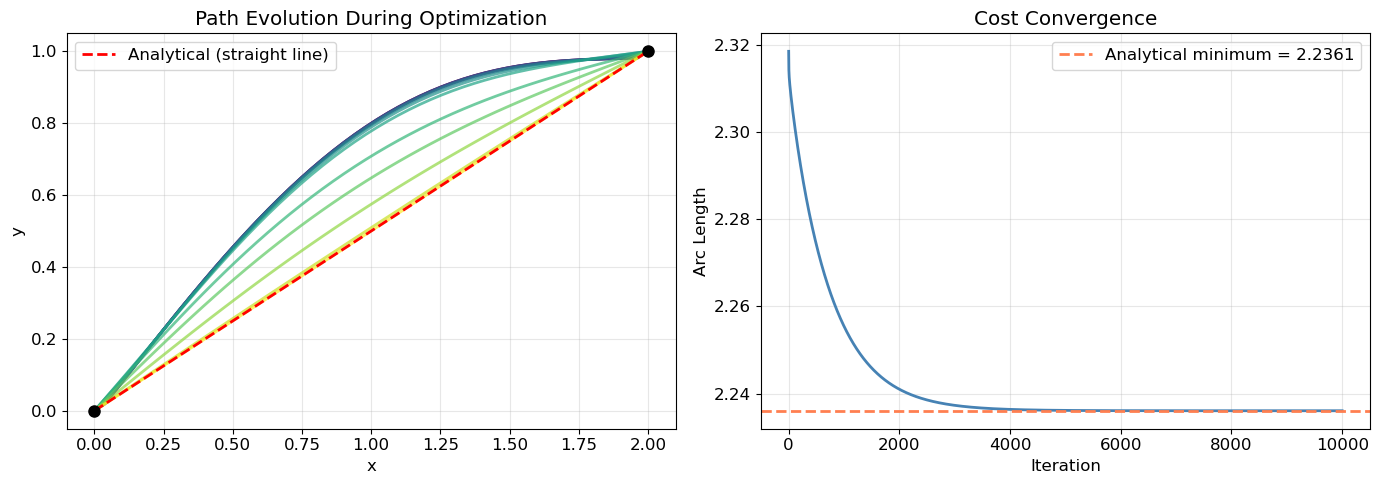

In [7]:
# ---- 2-Panel Figure: Path Evolution & Cost Convergence ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: path evolution
ax = axes[0]
n_traj = len(traj_hist_arc)
colors = plt.cm.viridis(np.linspace(0, 1, n_traj))
for idx, traj in enumerate(traj_hist_arc):
    y_full = np.concatenate([[Y_START], traj, [Y_END]])
    ax.plot(x_coords, y_full, color=colors[idx], alpha=0.7)
# Analytical solution
ax.plot(x_coords, np.linspace(Y_START, Y_END, len(x_coords)), 'r--', linewidth=2, label='Analytical (straight line)')
ax.plot([X_START, X_END], [Y_START, Y_END], 'ko', markersize=8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Path Evolution During Optimization')
ax.legend()

# Right: cost convergence
ax = axes[1]
ax.plot(cost_hist_arc, color='steelblue', linewidth=2)
ax.axhline(analytical_length, color='coral', linestyle='--', linewidth=2, label=f'Analytical minimum = {analytical_length:.4f}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Arc Length')
ax.set_title('Cost Convergence')
ax.legend()

plt.tight_layout()
plt.show()

In [8]:
# ---- Verification: Euler-Lagrange Equation ----
y_straight = np.linspace(Y_START, Y_END, N_POINTS + 2)[1:-1]
max_deviation = np.max(np.abs(y_opt_arc - y_straight))
status_dev = "PASS" if max_deviation < 1e-3 else "FAIL"
print(f"Max deviation from straight line: {max_deviation:.2e} [{status_dev}]")

# Check y'' ≈ 0 (Euler-Lagrange equation)
y_full_opt = np.concatenate([[Y_START], y_opt_arc, [Y_END]])
dx = x_coords[1] - x_coords[0]
y_pp = np.diff(y_full_opt, n=2) / dx**2
max_curvature = np.max(np.abs(y_pp))
status_el = "PASS" if max_curvature < 1e-2 else "FAIL"
print(f"Max |y''| (EL residual):         {max_curvature:.2e} [{status_el}]")

Max deviation from straight line: 2.94e-04 [PASS]
Max |y''| (EL residual):         7.26e-04 [PASS]


---
# Part 2: The Brachistochrone Problem

*What is the curve of fastest descent under gravity?*

In 1696, Johann Bernoulli posed this challenge to the mathematicians of Europe: given two points $A$ and $B$ (with $B$ lower than $A$), find the curve along which a frictionless bead slides from $A$ to $B$ in the least time. Solutions were submitted by Newton, Leibniz, L'Hôpital, Jakob Bernoulli, and Tschirnhaus — making it one of the most celebrated problems in the history of mathematics.

## 7. Physics Setup

We adopt a coordinate system where **$y$ points downward** (so that $y > 0$ below the starting point). The bead starts from rest at the origin $(0, 0)$.

By conservation of energy, the speed at height $y$ is:

$$v = \sqrt{2gy}$$

An infinitesimal arc length element $ds = \sqrt{1 + y'^2} \, dx$ is traversed in time $dt = ds/v$. The total descent time is:

$$T[y] = \int_0^{x_1} \frac{\sqrt{1 + y'^2}}{\sqrt{2gy}} \, dx = \int_0^{x_1} \sqrt{\frac{1 + y'^2}{2gy}} \, dx$$

Here $F(y, y') = \sqrt{\frac{1 + y'^2}{2gy}}$, which has no explicit $x$-dependence — a perfect setup for the **Beltrami identity** (Case 2).

## 8. Analytical Solution: The Cycloid

Applying the Beltrami identity $F - y'F_{y'} = C$:

$$\sqrt{\frac{1+y'^2}{2gy}} - y' \cdot \frac{y'}{\sqrt{2gy(1+y'^2)}} = C$$

Simplifying:

$$\frac{1}{\sqrt{2gy(1+y'^2)}} = C \quad \Longrightarrow \quad y(1 + y'^2) = \frac{1}{2gC^2} \equiv 2R$$

Setting $y' = \cot(\theta/2)$ and letting $2R$ be the diameter, this yields the **cycloid** — the curve traced by a point on the rim of a circle of radius $R$ rolling along a horizontal line:

$$\boxed{x(\theta) = R(\theta - \sin\theta), \qquad y(\theta) = R(1 - \cos\theta)}$$

The descent time along the cycloid is:

$$T^* = \theta_{\text{end}} \sqrt{\frac{R}{g}}$$

where $\theta_{\text{end}}$ is determined by the endpoint conditions.

In [9]:
def cycloid_parametric(theta, radius):
    """Compute cycloid coordinates from parameter theta.

    Args:
        theta: Parameter values. Shape: (M,) or scalar.
        radius: Radius of the rolling circle. Scalar.

    Returns:
        x: Horizontal coordinates. Shape: same as theta.
        y: Vertical coordinates (downward positive). Shape: same as theta.
    """
    x = radius * (theta - np.sin(theta))
    y = radius * (1 - np.cos(theta))
    return x, y


def find_cycloid_radius(x_end, y_end, theta_bracket=(0.01, 2 * np.pi - 0.01)):
    """Find the cycloid radius R and endpoint parameter theta_end.

    Solves x_end * (1 - cos(theta)) - y_end * (theta - sin(theta)) = 0.

    Args:
        x_end: Target x-coordinate. Scalar.
        y_end: Target y-coordinate. Scalar.
        theta_bracket: Bracket for root finding. Tuple of (lo, hi).

    Returns:
        radius: Cycloid radius. Scalar.
        theta_end: Parameter value at endpoint. Scalar.
    """
    def equation(theta):
        return x_end * (1 - np.cos(theta)) - y_end * (theta - np.sin(theta))

    theta_end = brentq(equation, *theta_bracket)
    radius = y_end / (1 - np.cos(theta_end))
    return radius, theta_end

Cycloid radius R = 0.258600
Endpoint parameter theta_end = 3.508369 rad


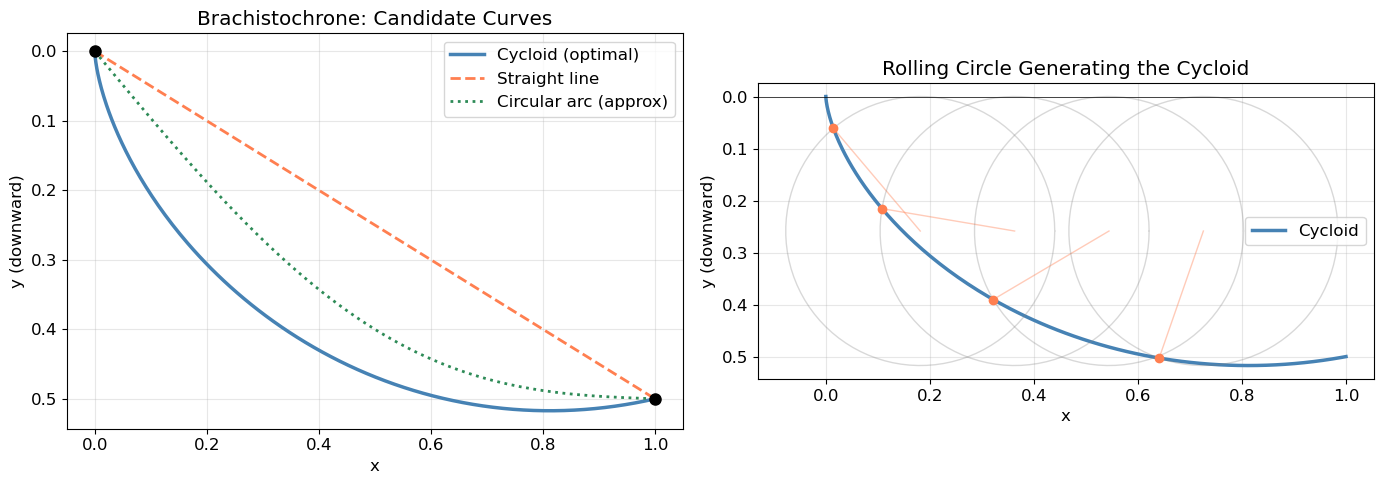

In [10]:
# ---- 2-Panel: Cycloid vs Alternatives + Rolling Circle ----
radius, theta_end = find_cycloid_radius(BRACH_X_END, BRACH_Y_END)
print(f"Cycloid radius R = {radius:.6f}")
print(f"Endpoint parameter theta_end = {theta_end:.6f} rad")

theta_fine = np.linspace(0, theta_end, 200)
x_cyc, y_cyc = cycloid_parametric(theta_fine, radius)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: compare curves
ax = axes[0]
ax.plot(x_cyc, y_cyc, color='steelblue', linewidth=2.5, label='Cycloid (optimal)')
ax.plot([0, BRACH_X_END], [0, BRACH_Y_END], 'coral', linewidth=2, linestyle='--', label='Straight line')
# Circular arc
t_arc = np.linspace(0, 1, 200)
# Find circle through (0,0) and (x1,y1) that is "sagging"
cx, cy = BRACH_X_END / 2, 0.0
r_arc = np.sqrt(cx**2 + cy**2)
arc_x = BRACH_X_END * t_arc
arc_y = BRACH_Y_END * t_arc + 0.15 * np.sin(np.pi * t_arc)  # simple bulging curve as alternative
ax.plot(arc_x, arc_y, color='seagreen', linewidth=2, linestyle=':', label='Circular arc (approx)')
ax.plot([0, BRACH_X_END], [0, BRACH_Y_END], 'ko', markersize=8, zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y (downward)')
ax.set_title('Brachistochrone: Candidate Curves')
ax.legend()
ax.invert_yaxis()

# Right: rolling circle visualization
ax = axes[1]
ax.plot(x_cyc, y_cyc, color='steelblue', linewidth=2.5, label='Cycloid')
# Show rolling circle at a few positions
for t_pos in [0.2, 0.4, 0.6, 0.8]:
    theta_pos = t_pos * theta_end
    cx_pos = radius * theta_pos  # center x
    cy_pos = radius                # center y (constant for rolling on y=0 line inverted)
    circle_angles = np.linspace(0, 2 * np.pi, 100)
    ax.plot(cx_pos + radius * np.cos(circle_angles),
            cy_pos - radius * np.sin(circle_angles),
            color='gray', alpha=0.3, linewidth=1)
    # Point on rim
    px, py = cycloid_parametric(theta_pos, radius)
    ax.plot(px, py, 'o', color='coral', markersize=6, zorder=5)
    # Line from center to point
    ax.plot([cx_pos, px], [cy_pos - radius + radius, py], color='coral', alpha=0.4, linewidth=1)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y (downward)')
ax.set_title('Rolling Circle Generating the Cycloid')
ax.legend()
ax.set_aspect('equal')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [11]:
def compute_descent_time(y_interior, x_coords, y_start, y_end, g=GRAVITY):
    """Compute descent time for a bead sliding along the discretized curve.

    Uses the exact integral for each segment (assuming y varies linearly):
        tau_j = 2 * ds_j / (v_j + v_{j+1})
    where v_j = sqrt(2*g*y_j). This correctly handles the y=0 singularity.

    Args:
        y_interior: Interior y-values (downward positive). Shape: (N,).
        x_coords: All x-coordinates including endpoints. Shape: (N+2,).
        y_start: Starting y-value. Scalar.
        y_end: Ending y-value. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        Total descent time. Scalar.
    """
    y_full = np.concatenate([[y_start], y_interior, [y_end]])
    dx = np.diff(x_coords)
    dy = np.diff(y_full)
    ds = np.sqrt(dx**2 + dy**2)

    # Speed at each node: v = sqrt(2*g*y), with y clamped >= 0
    v = np.sqrt(2 * g * np.maximum(y_full, 0.0))

    # Sum of endpoint speeds for each segment
    v_sum = v[:-1] + v[1:]
    v_sum = np.maximum(v_sum, 1e-15)  # avoid div-by-zero if both endpoints at y=0

    return np.sum(2.0 * ds / v_sum)


# Compare descent times for different curves
x_brach = np.linspace(0, BRACH_X_END, N_POINTS_BRACH + 2)

# Straight line
y_straight_brach = np.linspace(0, BRACH_Y_END, N_POINTS_BRACH + 2)[1:-1]
t_straight = compute_descent_time(y_straight_brach, x_brach, 0.0, BRACH_Y_END)

# Circular arc (bulging curve)
t_interior = np.linspace(0, 1, N_POINTS_BRACH + 2)[1:-1]
y_arc_brach = BRACH_Y_END * t_interior + 0.15 * np.sin(np.pi * t_interior)
t_arc = compute_descent_time(y_arc_brach, x_brach, 0.0, BRACH_Y_END)

# Analytical cycloid
theta_pts = np.linspace(0, theta_end, N_POINTS_BRACH + 2)
x_cyc_pts, y_cyc_pts = cycloid_parametric(theta_pts, radius)
# Interpolate cycloid onto uniform x grid
cyc_interp = interp1d(x_cyc_pts, y_cyc_pts, kind='cubic')
y_cyc_on_grid = cyc_interp(x_brach[1:-1])
t_cycloid_num = compute_descent_time(y_cyc_on_grid, x_brach, 0.0, BRACH_Y_END)

# Analytical cycloid time
t_cycloid_analytical = theta_end * np.sqrt(radius / GRAVITY)

print(f"Descent times:")
print(f"  Straight line:           {t_straight:.6f} s")
print(f"  Circular arc (approx):   {t_arc:.6f} s")
print(f"  Cycloid (numerical):     {t_cycloid_num:.6f} s")
print(f"  Cycloid (analytical):    {t_cycloid_analytical:.6f} s")

Descent times:
  Straight line:           0.713922 s
  Circular arc (approx):   0.608063 s
  Cycloid (numerical):     0.570542 s
  Cycloid (analytical):    0.569620 s


## 9. Numerical Optimization of the Brachistochrone

This problem is significantly harder to optimize than the arc length problem:

1. **Singularity at $y = 0$:** The integrand diverges as $y \to 0$, so the first segment near the origin requires careful handling.
2. **Stiffer gradients:** The coupling between slope and height makes the gradient landscape less smooth.
3. **Positivity constraint:** $y$ must remain positive (the bead must stay below the starting height).

While gradient descent worked for the arc length, the Brachistochrone needs a more powerful optimizer. We use **L-BFGS-B** (Limited-memory BFGS with Bounds) — a quasi-Newton method that:
- Approximates the Hessian using gradient history, giving much faster convergence than steepest descent
- Natively supports **bound constraints** $y_i \geq 10^{-6}$ to enforce positivity

In [12]:
def compute_descent_time_gradient(y_interior, x_coords, y_start, y_end, g=GRAVITY):
    """Compute gradient of descent time w.r.t. interior y-values.

    Matches the exact segment formula: tau_j = 2*ds_j / (v_j + v_{j+1}).
    Each y_i affects two adjacent segments through both ds (slope) and v (speed).

    Args:
        y_interior: Interior y-values (downward positive). Shape: (N,).
        x_coords: All x-coordinates including endpoints. Shape: (N+2,).
        y_start: Starting y-value. Scalar.
        y_end: Ending y-value. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        Gradient of descent time. Shape: (N,).
    """
    y_full = np.concatenate([[y_start], y_interior, [y_end]])
    dx = np.diff(x_coords)
    dy = np.diff(y_full)
    ds = np.sqrt(dx**2 + dy**2)

    # Match clamping in compute_descent_time: max(y, 0)
    v = np.sqrt(2 * g * np.maximum(y_full, 0.0))

    v_sum = v[:-1] + v[1:]
    v_sum = np.maximum(v_sum, 1e-15)

    # dv/dy for interior points only (endpoints are fixed, avoid div-by-zero at y=0)
    y_int_safe = np.maximum(y_interior, 1e-10)
    v_int = np.sqrt(2 * g * y_int_safe)
    dv_dy = g / v_int  # shape: (N,)

    n = len(y_interior)
    grad = np.zeros(n)

    for i in range(n):
        # --- Segment i: from y_full[i] to y_full[i+1] ---
        # tau_i = 2 * ds[i] / v_sum[i]
        grad[i] += 2.0 * (
            dy[i] / ds[i] / v_sum[i]
            - ds[i] * dv_dy[i] / v_sum[i]**2
        )

        # --- Segment i+1: from y_full[i+1] to y_full[i+2] ---
        # tau_{i+1} = 2 * ds[i+1] / v_sum[i+1]
        grad[i] += 2.0 * (
            -dy[i + 1] / ds[i + 1] / v_sum[i + 1]
            - ds[i + 1] * dv_dy[i] / v_sum[i + 1]**2
        )

    return grad

In [13]:
# ---- Gradient Verification (Descent Time) ----
x_brach_test = np.linspace(0, BRACH_X_END, N_POINTS_BRACH + 2)
# Use a test curve that stays well away from y=0
t_test = np.linspace(0, 1, N_POINTS_BRACH + 2)[1:-1]
y_test_brach = BRACH_Y_END * t_test + 0.05 * np.sin(np.pi * t_test)

analytical_grad_brach = compute_descent_time_gradient(y_test_brach, x_brach_test, 0.0, BRACH_Y_END)

numerical_grad_brach = np.zeros_like(y_test_brach)
for i in range(len(y_test_brach)):
    y_plus = y_test_brach.copy()
    y_minus = y_test_brach.copy()
    y_plus[i] += FD_EPSILON
    y_minus[i] -= FD_EPSILON
    numerical_grad_brach[i] = (
        compute_descent_time(y_plus, x_brach_test, 0.0, BRACH_Y_END)
        - compute_descent_time(y_minus, x_brach_test, 0.0, BRACH_Y_END)
    ) / (2 * FD_EPSILON)

rel_error_brach = np.max(
    np.abs(analytical_grad_brach - numerical_grad_brach) / (np.abs(numerical_grad_brach) + 1e-12)
)
status_brach = "PASS" if rel_error_brach < 1e-5 else "FAIL"
print(f"Descent time gradient check: max relative error = {rel_error_brach:.2e} [{status_brach}]")

Descent time gradient check: max relative error = 6.63e-07 [PASS]


In [14]:
from scipy.optimize import minimize


def optimize_brachistochrone(y_init, x_coords, y_start, y_end, max_iter=500, g=GRAVITY):
    """Minimize descent time via L-BFGS-B with positivity bounds.

    Args:
        y_init: Initial interior y-values. Shape: (N,).
        x_coords: All x-coordinates including endpoints. Shape: (N+2,).
        y_start: Starting y-value. Scalar.
        y_end: Ending y-value. Scalar.
        max_iter: Maximum number of L-BFGS-B iterations. Integer.
        g: Gravitational acceleration. Scalar.

    Returns:
        y_opt: Optimized interior y-values. Shape: (N,).
        cost_history: List of descent times at each iteration.
        trajectory_history: List of y_interior arrays at selected iterations.
    """
    cost_history = []
    trajectory_history = []
    iter_count = [0]
    save_iters = {0, 1, 2, 5, 10, 20, 50, 100, 200, 500}

    # Record initial state
    cost_history.append(compute_descent_time(y_init, x_coords, y_start, y_end, g))
    trajectory_history.append(y_init.copy())

    def callback(xk):
        cost = compute_descent_time(xk, x_coords, y_start, y_end, g)
        cost_history.append(cost)
        iter_count[0] += 1
        if iter_count[0] in save_iters:
            trajectory_history.append(xk.copy())

    n = len(y_init)
    bounds = [(1e-6, None)] * n

    result = minimize(
        compute_descent_time,
        y_init,
        args=(x_coords, y_start, y_end, g),
        jac=compute_descent_time_gradient,
        method='L-BFGS-B',
        bounds=bounds,
        callback=callback,
        options={'maxiter': max_iter, 'ftol': 1e-15, 'gtol': 1e-12},
    )

    # Record final state
    cost_history.append(compute_descent_time(result.x, x_coords, y_start, y_end, g))
    trajectory_history.append(result.x.copy())

    return result.x, cost_history, trajectory_history

In [15]:
# ---- Run Brachistochrone Optimization ----
x_brach = np.linspace(0, BRACH_X_END, N_POINTS_BRACH + 2)

# Start from the straight line
y_init_brach = np.linspace(0, BRACH_Y_END, N_POINTS_BRACH + 2)[1:-1]
# Ensure positivity for the first point
y_init_brach = np.maximum(y_init_brach, 1e-6)

y_opt_brach, cost_hist_brach, traj_hist_brach = optimize_brachistochrone(
    y_init_brach, x_brach, 0.0, BRACH_Y_END, MAX_ITER_BRACH
)

print(f"Initial descent time:    {cost_hist_brach[0]:.6f} s")
print(f"Final descent time:      {cost_hist_brach[-1]:.6f} s")
print(f"Analytical cycloid time: {t_cycloid_analytical:.6f} s")
print(f"Relative error:          {abs(cost_hist_brach[-1] - t_cycloid_analytical) / t_cycloid_analytical:.4%}")
print(f"L-BFGS-B iterations:     {len(cost_hist_brach) - 1}")

Initial descent time:    0.713922 s
Final descent time:      0.570471 s
Analytical cycloid time: 0.569620 s
Relative error:          0.1494%
L-BFGS-B iterations:     261


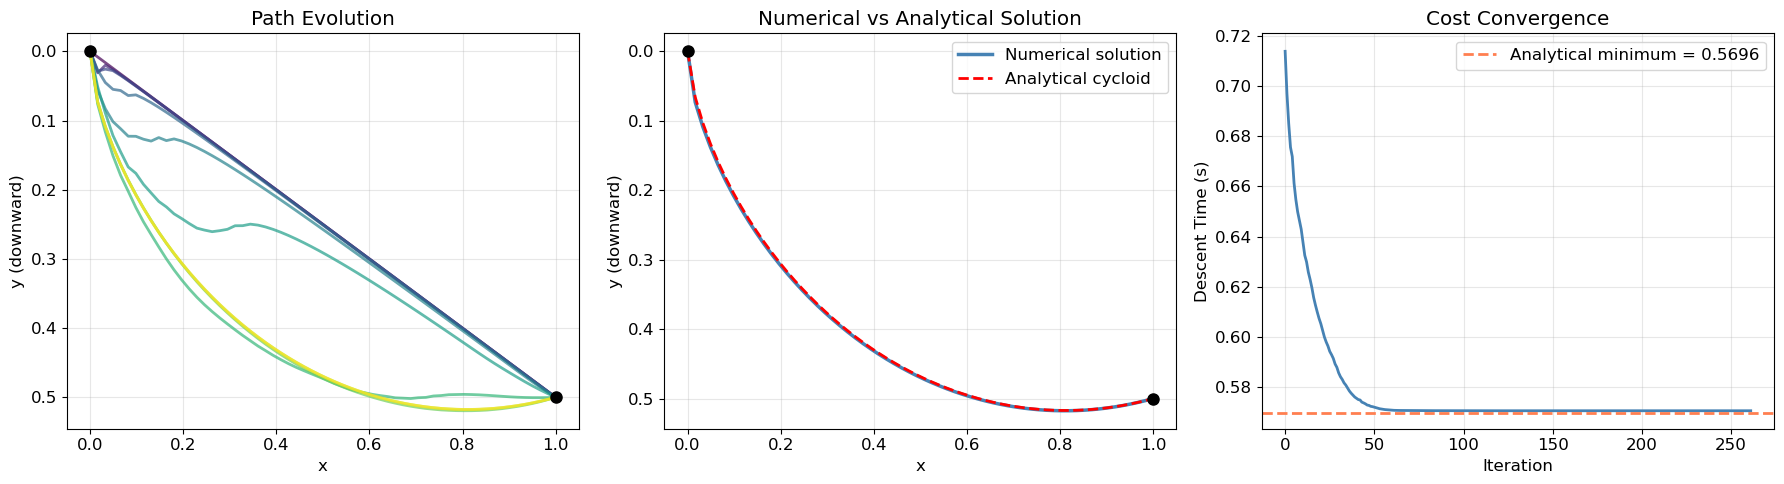

In [16]:
# ---- 3-Panel Figure: Brachistochrone Results ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: path evolution
ax = axes[0]
n_traj = len(traj_hist_brach)
colors = plt.cm.viridis(np.linspace(0, 1, n_traj))
for idx, traj in enumerate(traj_hist_brach):
    y_full = np.concatenate([[0.0], traj, [BRACH_Y_END]])
    ax.plot(x_brach, y_full, color=colors[idx], alpha=0.7)
ax.plot([0, BRACH_X_END], [0, BRACH_Y_END], 'ko', markersize=8, zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y (downward)')
ax.set_title('Path Evolution')
ax.invert_yaxis()

# Panel 2: numerical vs analytical cycloid
ax = axes[1]
y_full_opt = np.concatenate([[0.0], y_opt_brach, [BRACH_Y_END]])
ax.plot(x_brach, y_full_opt, color='steelblue', linewidth=2.5, label='Numerical solution')
# Interpolate cycloid onto the same grid
y_cyc_grid = cyc_interp(x_brach)
ax.plot(x_brach, y_cyc_grid, 'r--', linewidth=2, label='Analytical cycloid')
ax.plot([0, BRACH_X_END], [0, BRACH_Y_END], 'ko', markersize=8, zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y (downward)')
ax.set_title('Numerical vs Analytical Solution')
ax.legend()
ax.invert_yaxis()

# Panel 3: cost convergence
ax = axes[2]
ax.plot(cost_hist_brach, color='steelblue', linewidth=2)
ax.axhline(t_cycloid_analytical, color='coral', linestyle='--', linewidth=2,
           label=f'Analytical minimum = {t_cycloid_analytical:.4f}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Descent Time (s)')
ax.set_title('Cost Convergence')
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
# ---- Quantitative Verification ----
# Interpolate analytical cycloid onto the optimization grid
y_cyc_verification = cyc_interp(x_brach[1:-1])
deviation = np.abs(y_opt_brach - y_cyc_verification)
max_dev = np.max(deviation)
rms_dev = np.sqrt(np.mean(deviation**2))

status_max = "PASS" if max_dev < 0.01 else "FAIL"
status_rms = "PASS" if rms_dev < 0.005 else "FAIL"
status_time = "PASS" if abs(cost_hist_brach[-1] - t_cycloid_analytical) / t_cycloid_analytical < 0.01 else "FAIL"

print(f"Max deviation from cycloid:  {max_dev:.6f} [{status_max}]")
print(f"RMS deviation from cycloid:  {rms_dev:.6f} [{status_rms}]")
print(f"Descent time relative error: {abs(cost_hist_brach[-1] - t_cycloid_analytical) / t_cycloid_analytical:.4%} [{status_time}]")

Max deviation from cycloid:  0.007205 [PASS]
RMS deviation from cycloid:  0.002123 [PASS]
Descent time relative error: 0.1494% [PASS]


---
## 10. Sensitivity Analysis

In [18]:
# ---- Sweep over number of discretization points ----
n_values = [10, 20, 40, 60, 80, 100]
final_times = []
max_deviations = []

for n in n_values:
    x_grid = np.linspace(0, BRACH_X_END, n + 2)
    y_init = np.linspace(0, BRACH_Y_END, n + 2)[1:-1]
    y_init = np.maximum(y_init, 1e-6)

    y_opt_n, cost_hist_n, _ = optimize_brachistochrone(
        y_init, x_grid, 0.0, BRACH_Y_END, MAX_ITER_BRACH
    )

    final_times.append(cost_hist_n[-1])

    # Deviation from analytical cycloid
    y_cyc_n = cyc_interp(x_grid[1:-1])
    max_deviations.append(np.max(np.abs(y_opt_n - y_cyc_n)))

    print(f"N={n:3d}: T={cost_hist_n[-1]:.6f} s, max_dev={max_deviations[-1]:.6f}, iters={len(cost_hist_n)-1}")

print(f"\nAnalytical time: {t_cycloid_analytical:.6f} s")

N= 10: T=0.574793 s, max_dev=0.024037, iters=32
N= 20: T=0.572204 s, max_dev=0.015132, iters=72
N= 40: T=0.570903 s, max_dev=0.009477, iters=150
N= 60: T=0.570471 s, max_dev=0.007205, iters=261
N= 80: T=0.570256 s, max_dev=0.005933, iters=350
N=100: T=0.570128 s, max_dev=0.005104, iters=332

Analytical time: 0.569620 s


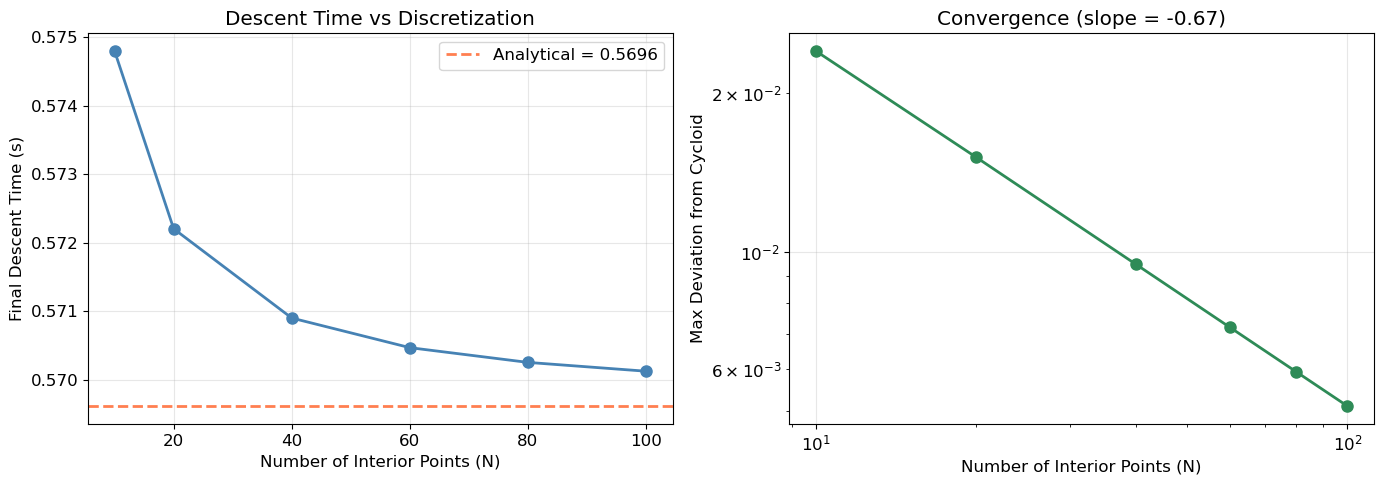

In [19]:
# ---- 2-Panel: Sensitivity Analysis ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: descent time vs N
ax = axes[0]
ax.plot(n_values, final_times, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axhline(t_cycloid_analytical, color='coral', linestyle='--', linewidth=2,
           label=f'Analytical = {t_cycloid_analytical:.4f}')
ax.set_xlabel('Number of Interior Points (N)')
ax.set_ylabel('Final Descent Time (s)')
ax.set_title('Descent Time vs Discretization')
ax.legend()

# Right: log-log deviation vs N
ax = axes[1]
ax.loglog(n_values, max_deviations, 'o-', color='seagreen', linewidth=2, markersize=8)
# Fit convergence order
log_n = np.log(np.array(n_values, dtype=float))
log_dev = np.log(np.array(max_deviations))
coeffs = np.polyfit(log_n, log_dev, 1)
ax.set_xlabel('Number of Interior Points (N)')
ax.set_ylabel('Max Deviation from Cycloid')
ax.set_title(f'Convergence (slope = {coeffs[0]:.2f})')

plt.tight_layout()
plt.show()

---
## 11. Comparative Analysis

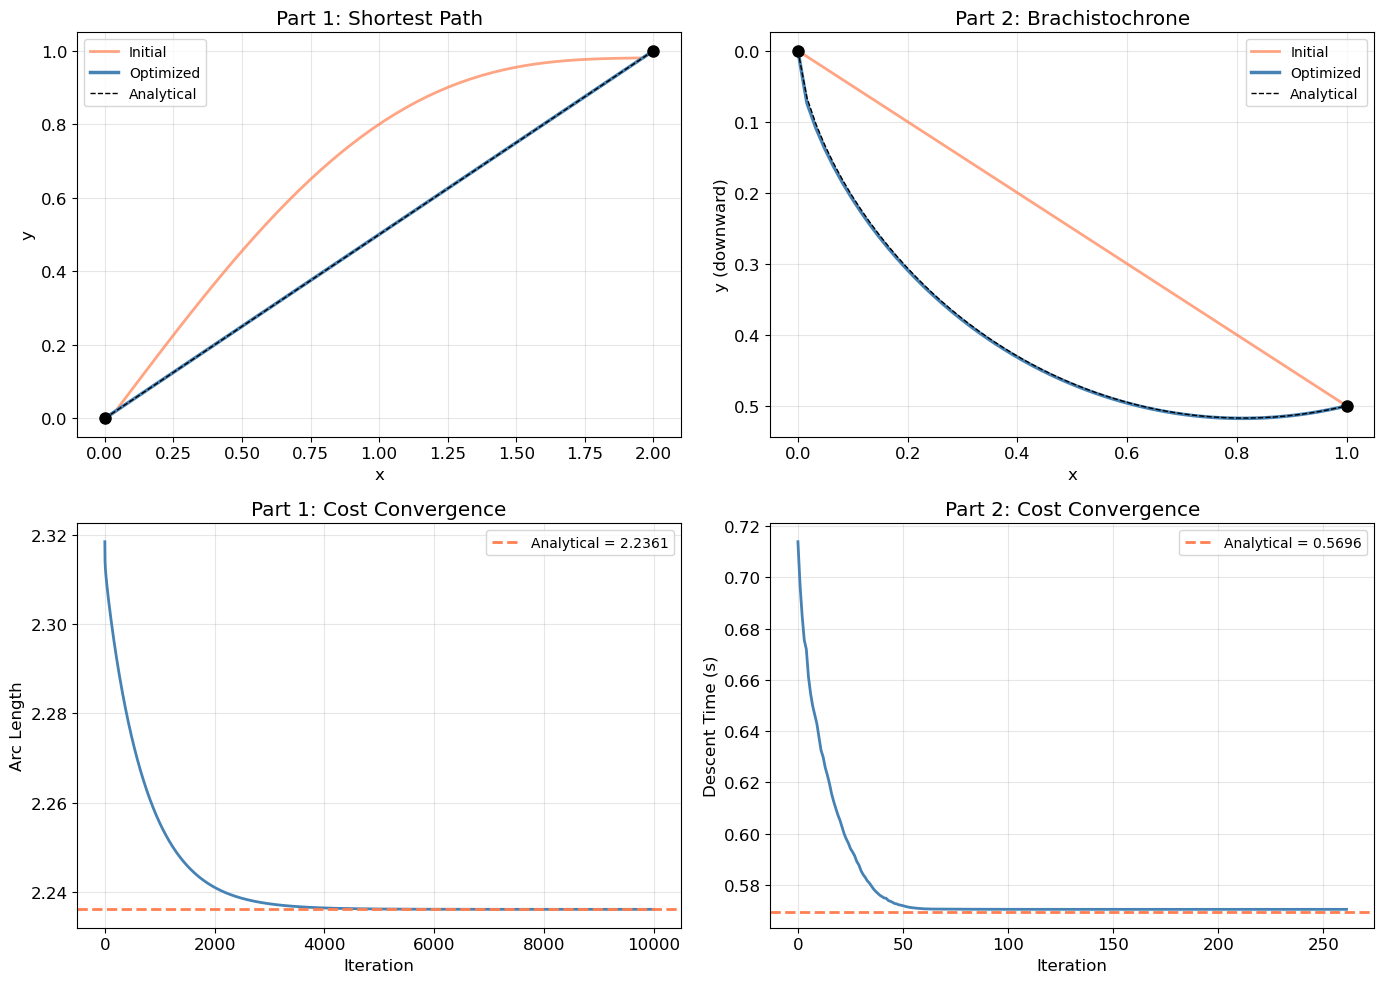

In [20]:
# ---- 4-Panel (2x2): Side-by-side comparison ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Arc length paths
ax = axes[0, 0]
y_full_init_arc = np.concatenate([[Y_START], traj_hist_arc[0], [Y_END]])
y_full_final_arc = np.concatenate([[Y_START], y_opt_arc, [Y_END]])
ax.plot(x_coords, y_full_init_arc, color='coral', linewidth=2, alpha=0.7, label='Initial')
ax.plot(x_coords, y_full_final_arc, color='steelblue', linewidth=2.5, label='Optimized')
ax.plot(x_coords, np.linspace(Y_START, Y_END, len(x_coords)), 'k--', linewidth=1, label='Analytical')
ax.plot([X_START, X_END], [Y_START, Y_END], 'ko', markersize=8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Part 1: Shortest Path')
ax.legend(fontsize=10)

# Top-right: Brachistochrone paths
ax = axes[0, 1]
y_full_init_brach = np.concatenate([[0.0], traj_hist_brach[0], [BRACH_Y_END]])
y_full_final_brach = np.concatenate([[0.0], y_opt_brach, [BRACH_Y_END]])
ax.plot(x_brach, y_full_init_brach, color='coral', linewidth=2, alpha=0.7, label='Initial')
ax.plot(x_brach, y_full_final_brach, color='steelblue', linewidth=2.5, label='Optimized')
ax.plot(x_brach, y_cyc_grid, 'k--', linewidth=1, label='Analytical')
ax.plot([0, BRACH_X_END], [0, BRACH_Y_END], 'ko', markersize=8)
ax.set_xlabel('x')
ax.set_ylabel('y (downward)')
ax.set_title('Part 2: Brachistochrone')
ax.legend(fontsize=10)
ax.invert_yaxis()

# Bottom-left: Arc length convergence
ax = axes[1, 0]
ax.plot(cost_hist_arc, color='steelblue', linewidth=2)
ax.axhline(analytical_length, color='coral', linestyle='--', linewidth=2,
           label=f'Analytical = {analytical_length:.4f}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Arc Length')
ax.set_title('Part 1: Cost Convergence')
ax.legend(fontsize=10)

# Bottom-right: Brachistochrone convergence
ax = axes[1, 1]
ax.plot(cost_hist_brach, color='steelblue', linewidth=2)
ax.axhline(t_cycloid_analytical, color='coral', linestyle='--', linewidth=2,
           label=f'Analytical = {t_cycloid_analytical:.4f}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Descent Time (s)')
ax.set_title('Part 2: Cost Convergence')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

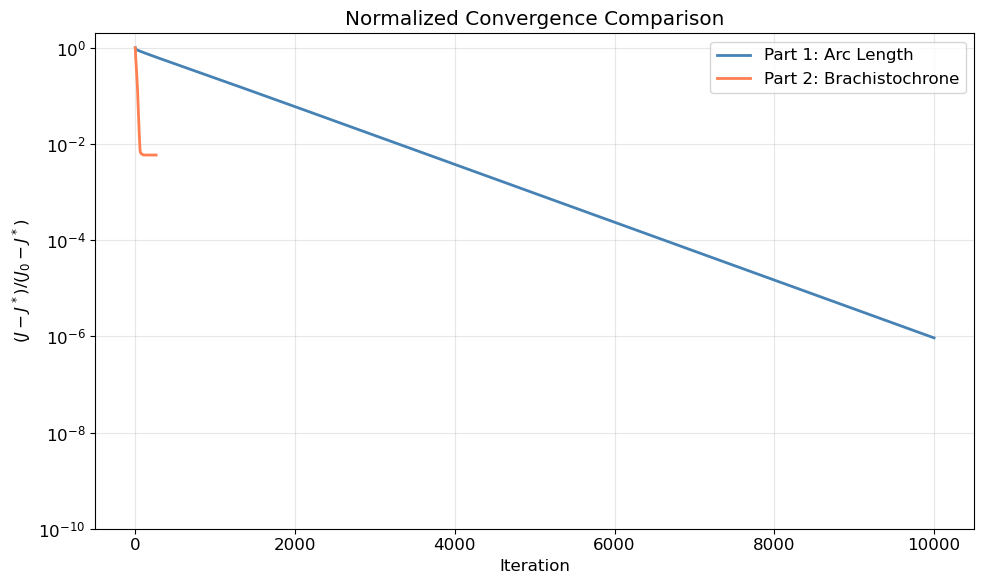

In [21]:
# ---- Normalized Convergence Comparison ----
fig, ax = plt.subplots(figsize=(10, 6))

# Normalize: (J - J*) / (J_0 - J*)
j0_arc = cost_hist_arc[0]
jstar_arc = analytical_length
norm_arc = [(j - jstar_arc) / (j0_arc - jstar_arc) for j in cost_hist_arc]

j0_brach = cost_hist_brach[0]
jstar_brach = t_cycloid_analytical
norm_brach = [(j - jstar_brach) / (j0_brach - jstar_brach) for j in cost_hist_brach]

ax.semilogy(norm_arc, color='steelblue', linewidth=2, label='Part 1: Arc Length')
ax.semilogy(norm_brach, color='coral', linewidth=2, label='Part 2: Brachistochrone')
ax.set_xlabel('Iteration')
ax.set_ylabel('$(J - J^*) / (J_0 - J^*)$')
ax.set_title('Normalized Convergence Comparison')
ax.legend(fontsize=12)
ax.set_ylim(bottom=1e-10)

plt.tight_layout()
plt.show()

## 12. Discussion

### Why Does the Arc Length Problem Converge So Much Faster?

The arc length functional is **convex** — any local minimum is the global minimum, and the Hessian is well-conditioned. The Brachistochrone functional, while still having a unique minimum (the cycloid), has a more challenging landscape due to the $1/\sqrt{y}$ singularity and the coupling between slope and height.

### Applications of the Calculus of Variations

| Domain | Problem | Functional |
|--------|---------|------------|
| **Classical Mechanics** | Least action principle | $S[q] = \int L(q, \dot{q}, t) \, dt$ |
| **Optics** | Fermat's principle (shortest optical path) | $T[\gamma] = \int n(\mathbf{r}) \, ds$ |
| **Differential Geometry** | Geodesics on surfaces | $L[\gamma] = \int \sqrt{g_{ij} \dot{x}^i \dot{x}^j} \, dt$ |
| **Soap Films** | Minimal surfaces (Plateau's problem) | $A[z] = \iint \sqrt{1 + z_x^2 + z_y^2} \, dx \, dy$ |
| **Quantum Mechanics** | Schrödinger equation via variational principle | $E[\psi] = \langle\psi|H|\psi\rangle / \langle\psi|\psi\rangle$ |
| **Robotics** | CHOMP trajectory optimization | $U[\xi] = F_{\text{obs}}[\xi] + \lambda F_{\text{smooth}}[\xi]$ |

## 13. Extensions

This notebook has covered the simplest setting of the calculus of variations. Several natural extensions include:

### Isoperimetric Problems
Optimize $J[y]$ subject to a **constraint** $\int G(x, y, y') \, dx = C$. Use Lagrange multipliers to reduce to a modified EL equation. Classical example: maximize the area enclosed by a curve of fixed perimeter (answer: a circle).

### Higher Dimensions
For functions of several variables $u(x_1, \ldots, x_n)$, the EL equation becomes a **PDE:**
$$\frac{\partial F}{\partial u} - \sum_{i=1}^n \frac{\partial}{\partial x_i} \frac{\partial F}{\partial u_{x_i}} = 0$$
This governs minimal surfaces, elasticity, and field theories.

### Hamiltonian Mechanics
The Euler-Lagrange equation is the foundation of analytical mechanics. The Legendre transform converts the Lagrangian $L(q, \dot{q})$ to the Hamiltonian $H(q, p)$, yielding Hamilton's equations — the symplectic structure that underlies all of classical and quantum physics.

### Key Takeaways

1. The **Euler-Lagrange equation** is the fundamental necessary condition for extremals of functionals
2. **Special cases** (Beltrami identity, first integrals) often reduce the problem to solvable ODEs
3. **Numerical optimization** of variational problems follows naturally from discretization + gradient descent
4. **Gradient verification** via finite differences is essential for catching implementation errors
5. The calculus of variations connects seemingly disparate fields — from soap films to quantum mechanics to robot motion planning